In [5]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

print(torch.__version__)
print(torch.__file__)

2.13.0
/Users/denis/Desktop/coursework/Course_work_community_detection/.venv/lib/python3.13/site-packages/torch/__init__.py


In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("Torch path:", torch.__file__)

PyTorch: 2.13.0
CUDA: False
Torch path: /Users/denis/Desktop/coursework/Course_work_community_detection/.venv/lib/python3.13/site-packages/torch/__init__.py


In [3]:
import numpy as np

EMBEDDINGS_PATH = "../data/embeddings_sample.npy"

embeddings = np.load(EMBEDDINGS_PATH)

print("Shape:", embeddings.shape)
print("Dtype:", embeddings.dtype)
print("Min:", embeddings.min())
print("Max:", embeddings.max())
print("Mean:", embeddings.mean())
print("Std:", embeddings.std())

Shape: (1000, 312)
Dtype: float32
Min: -5.0598245
Max: 3.2596614
Mean: 0.018396575
Std: 0.6042406


In [4]:
norms = np.linalg.norm(embeddings, axis=1)

print("Norm min:", norms.min())
print("Norm max:", norms.max())
print("Norm mean:", norms.mean())
print("Zero vectors:", np.sum(norms < 1e-6))

Norm min: 8.777028
Norm max: 12.334148
Norm mean: 10.6661
Zero vectors: 0


In [6]:
pca = PCA(n_components=2)

embeddings_2d = pca.fit_transform(embeddings)

print("Исходная размерность:", embeddings.shape)
print("После PCA:", embeddings_2d.shape)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total explained variance:",
      pca.explained_variance_ratio_.sum())

Исходная размерность: (1000, 312)
После PCA: (1000, 2)
Explained variance ratio:
[0.12062652 0.07568733]
Total explained variance: 0.19631384


In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

embeddings_2d = pca.fit_transform(embeddings)

explained_variance = pca.explained_variance_ratio_

print("Исходная размерность:", embeddings.shape[1])
print("Размерность после PCA:", embeddings_2d.shape[1])

print(
    f"\nДоля объяснённой дисперсии:"
    f"\nPC1: {explained_variance[0] * 100:.2f}%"
    f"\nPC2: {explained_variance[1] * 100:.2f}%"
    f"\nСуммарно: {explained_variance.sum() * 100:.2f}%"
)

Исходная размерность: 312
Размерность после PCA: 2

Доля объяснённой дисперсии:
PC1: 12.06%
PC2: 7.57%
Суммарно: 19.63%


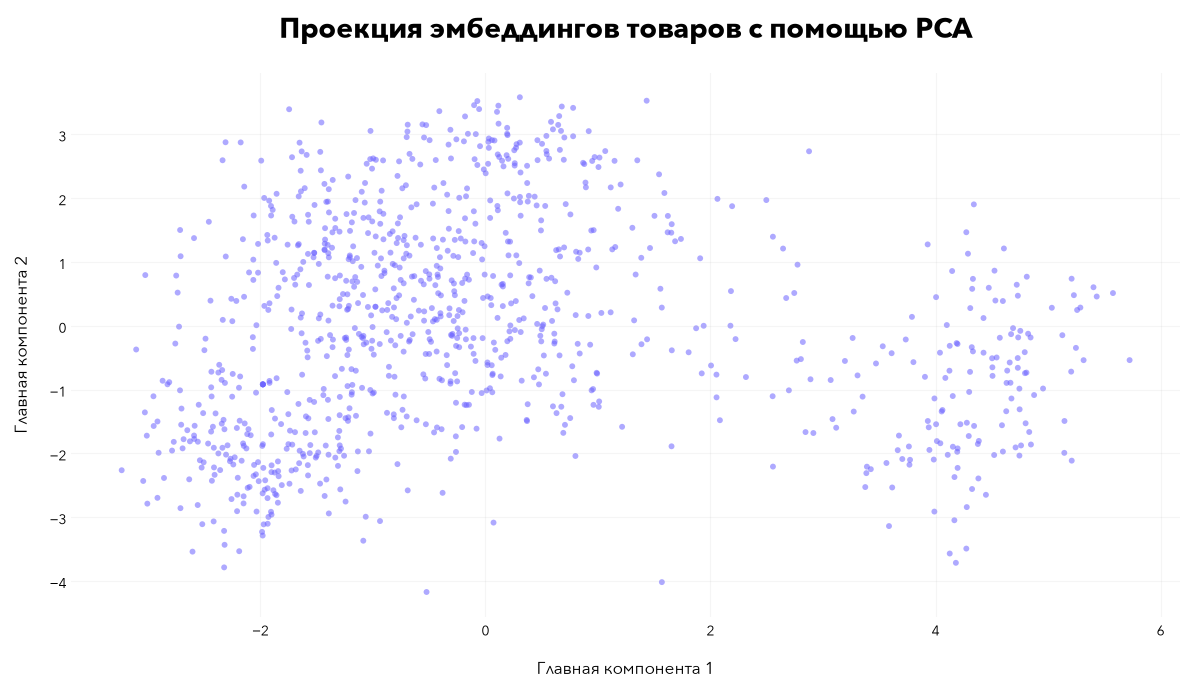

In [10]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Avenir Next"

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    s=18,
    alpha=0.55,
    color="#6C63FF",
    edgecolors="none"
)

ax.set_title(
    "Проекция эмбеддингов товаров с помощью PCA",
    fontsize=20,
    fontweight="bold",
    pad=25
)

ax.set_xlabel("Главная компонента 1", fontsize=12, labelpad=12)
ax.set_ylabel("Главная компонента 2", fontsize=12, labelpad=12)

# Убираем лишние элементы
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.tick_params(
    axis="both",
    which="both",
    length=0,
    labelsize=10
)

ax.grid(
    True,
    alpha=0.12,
    linewidth=0.8
)

plt.tight_layout()
plt.show()



### Вывод

Метод PCA позволяет представить 312-мерные эмбеддинги в двумерном пространстве. Каждая точка на графике соответствует отдельному товару.

По расположению точек можно предварительно оценить структуру пространства эмбеддингов: наличие плотных областей, удалённых групп и потенциальных кластеров.

При этом данная визуализация является только предварительным анализом. Поскольку файл `embeddings_sample.npy` содержит только эмбеддинги без соответствующих `category_id`, на данном этапе невозможно определить, насколько обнаруживаемые группы соответствуют реальным категориям товаров.

Для дальнейшего анализа необходимо связать эмбеддинги с `category_id` из исходного Parquet-файла и сравнить получаемые кластеры с исходной категоризацией товаров.

## Распределение значений эмбеддингов

Проверим распределение числовых значений внутри эмбеддингов.

Каждый товар представлен 312-мерным вектором, поэтому всего в выборке содержится 312 000 числовых значений. Гистограмма позволяет оценить диапазон значений и форму их распределения.

Это дополнительная проверка качества полученных эмбеддингов: наличие аномально больших значений или большого количества значений около нуля может указывать на особенности формирования векторных представлений.

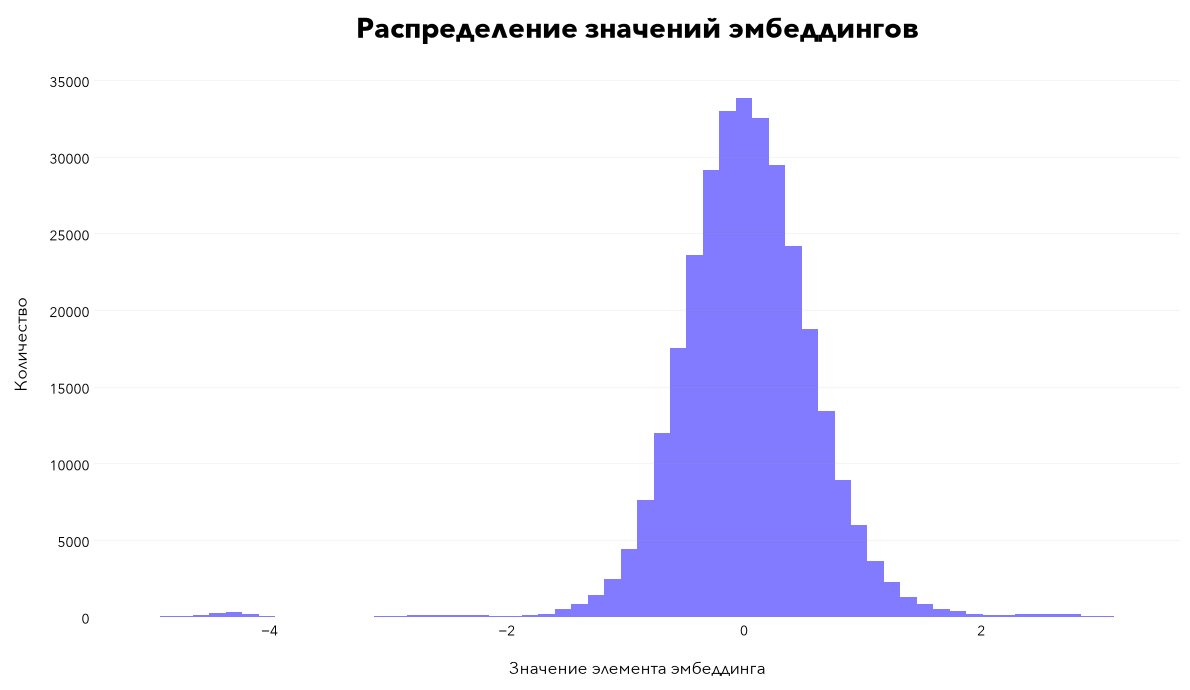

In [11]:
plt.rcParams["font.family"] = "Avenir Next"

fig, ax = plt.subplots(figsize=(12, 7))

ax.hist(
    embeddings.flatten(),
    bins=60,
    color="#6C63FF",
    alpha=0.85
)

ax.set_title(
    "Распределение значений эмбеддингов",
    fontsize=20,
    fontweight="bold",
    pad=25
)

ax.set_xlabel(
    "Значение элемента эмбеддинга",
    fontsize=12,
    labelpad=12
)

ax.set_ylabel(
    "Количество",
    fontsize=12,
    labelpad=12
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.tick_params(
    axis="both",
    which="both",
    length=0,
    labelsize=10
)

ax.grid(
    True,
    axis="y",
    alpha=0.12,
    linewidth=0.8
)

plt.tight_layout()
plt.show()

## Распределение норм эмбеддингов

Норма вектора показывает его длину в 312-мерном пространстве.

Если нормы сильно отличаются между товарами, это может означать различный масштаб векторных представлений. Если значения находятся в относительно узком диапазоне, эмбеддинги имеют более стабильный масштаб.

В дальнейшем это важно учитывать при выборе расстояния и алгоритма кластеризации.

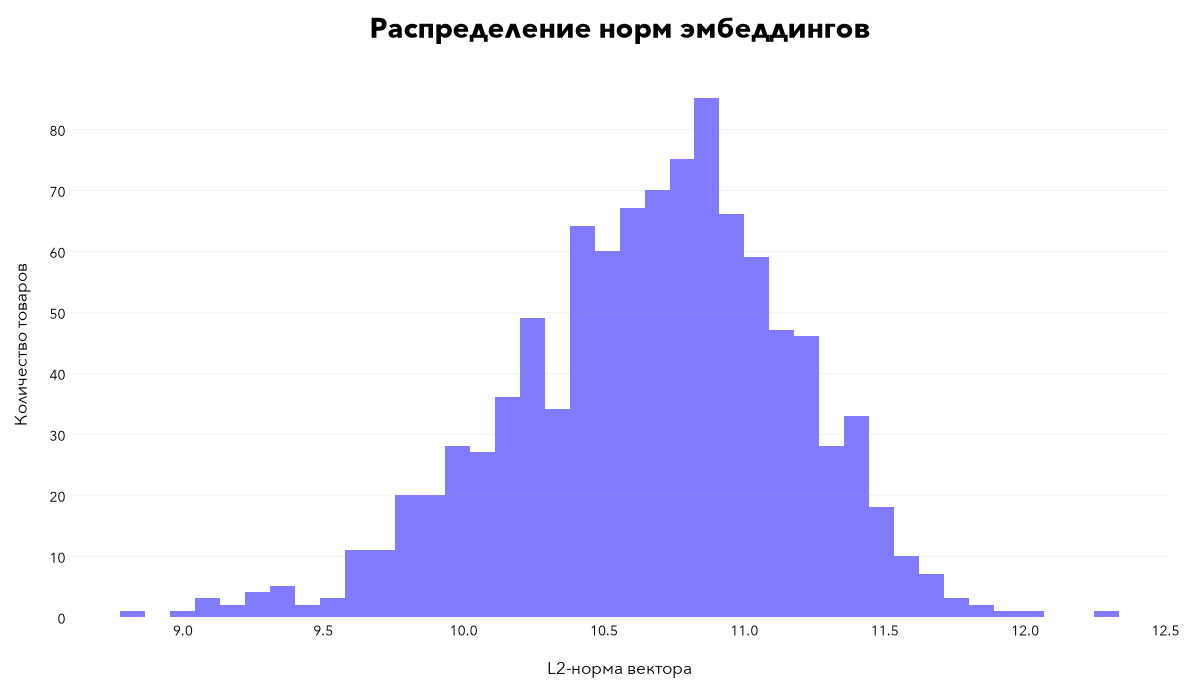

In [12]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.hist(
    norms,
    bins=40,
    color="#6C63FF",
    alpha=0.85
)

ax.set_title(
    "Распределение норм эмбеддингов",
    fontsize=20,
    fontweight="bold",
    pad=25
)

ax.set_xlabel(
    "L2-норма вектора",
    fontsize=12,
    labelpad=12
)

ax.set_ylabel(
    "Количество товаров",
    fontsize=12,
    labelpad=12
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.tick_params(
    axis="both",
    which="both",
    length=0,
    labelsize=10
)

ax.grid(
    True,
    axis="y",
    alpha=0.12,
    linewidth=0.8
)

plt.tight_layout()
plt.show()

### Вывод

Анализ эмбеддингов показывает, что все объекты представлены ненулевыми 312-мерными векторами типа `float32`. Значения элементов эмбеддингов находятся в конечном диапазоне, а нормы векторов не демонстрируют экстремальных значений.

PCA позволяет перейти от исходного 312-мерного пространства к двумерному представлению и визуально исследовать структуру данных. Однако для оценки соответствия структуры эмбеддингов реальным категориям товаров необходимо связать векторы с `category_id` из исходного датасета.

Следующим этапом является анализ кластерной структуры эмбеддингов с использованием алгоритмов кластеризации.

## Распределение косинусных расстояний

Перед кластеризацией полезно оценить, насколько различаются товары в пространстве эмбеддингов.

Используем косинусное расстояние. В отличие от обычного евклидова расстояния, оно оценивает различие направлений векторов и поэтому часто применяется для сравнения семантических эмбеддингов.

Для анализа рассмотрим случайную выборку пар товаров.

In [13]:
from sklearn.metrics import pairwise_distances

# Берём 500 случайных эмбеддингов
rng = np.random.default_rng(42)

sample_indices = rng.choice(
    len(embeddings),
    size=500,
    replace=False
)

embeddings_small = embeddings[sample_indices]

distances = pairwise_distances(
    embeddings_small,
    metric="cosine"
)

# Берём только верхний треугольник матрицы,
# чтобы не считать каждую пару дважды
upper_triangle = distances[
    np.triu_indices_from(distances, k=1)
]

print(f"Количество пар: {len(upper_triangle):,}")
print(f"Среднее расстояние: {upper_triangle.mean():.4f}")
print(f"Медиана: {np.median(upper_triangle):.4f}")
print(f"Минимум: {upper_triangle.min():.4f}")
print(f"Максимум: {upper_triangle.max():.4f}")

Количество пар: 124,750
Среднее расстояние: 0.3150
Медиана: 0.2985
Минимум: 0.0000
Максимум: 0.7045


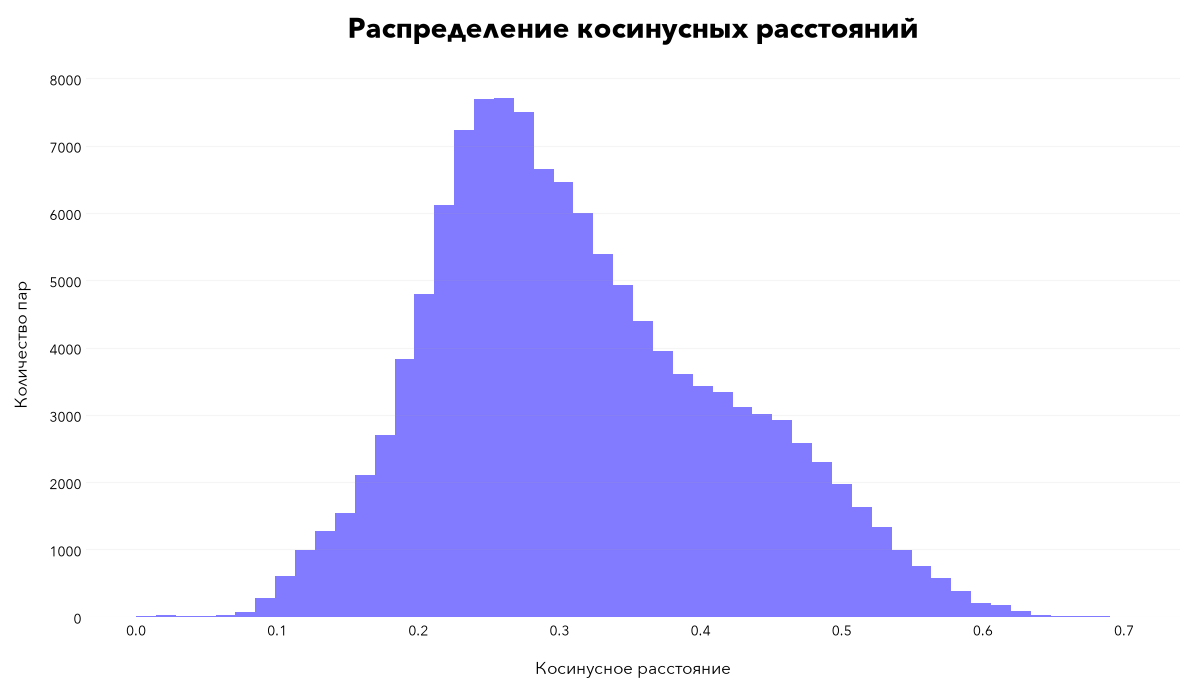

In [14]:
plt.rcParams["font.family"] = "Avenir Next"

fig, ax = plt.subplots(figsize=(12, 7))

ax.hist(
    upper_triangle,
    bins=50,
    color="#6C63FF",
    alpha=0.85
)

ax.set_title(
    "Распределение косинусных расстояний",
    fontsize=20,
    fontweight="bold",
    pad=25
)

ax.set_xlabel(
    "Косинусное расстояние",
    fontsize=12,
    labelpad=12
)

ax.set_ylabel(
    "Количество пар",
    fontsize=12,
    labelpad=12
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.tick_params(
    axis="both",
    which="both",
    length=0
)

ax.grid(
    True,
    axis="y",
    alpha=0.12
)

plt.tight_layout()
plt.show()

Зачем это нужно: если все расстояния почти одинаковые, пространство может быть плохо структурировано для кластеризации. Если распределение имеет заметную структуру, это хороший сигнал для дальнейших экспериментов.

## Масштаб отдельных компонент эмбеддинга

Рассмотрим среднее абсолютное значение каждой из 312 компонент.

Это позволяет проверить, равномерно ли используются компоненты эмбеддинга или отдельные измерения имеют существенно больший масштаб.

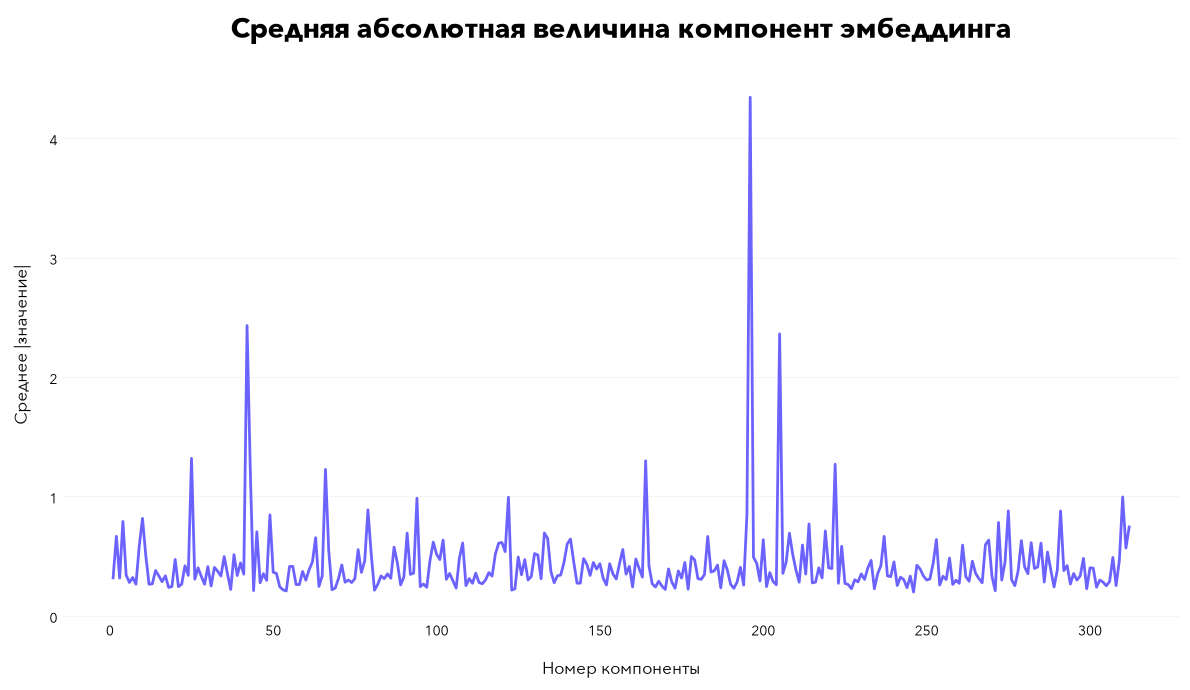

In [15]:
mean_abs = np.mean(np.abs(embeddings), axis=0)

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    np.arange(1, embeddings.shape[1] + 1),
    mean_abs,
    linewidth=2,
    color="#6C63FF"
)

ax.set_title(
    "Средняя абсолютная величина компонент эмбеддинга",
    fontsize=20,
    fontweight="bold",
    pad=25
)

ax.set_xlabel(
    "Номер компоненты",
    fontsize=12,
    labelpad=12
)

ax.set_ylabel(
    "Среднее |значение|",
    fontsize=12,
    labelpad=12
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.tick_params(axis="both", length=0)

ax.grid(
    True,
    axis="y",
    alpha=0.12
)

plt.tight_layout()
plt.show()

## Объяснённая дисперсия PCA

Проверим, какое количество компонент необходимо для сохранения основной части вариативности эмбеддингов.

Это позволяет понять, насколько сильно мы теряем информацию при снижении размерности и почему двумерное представление используется преимущественно для визуализации.

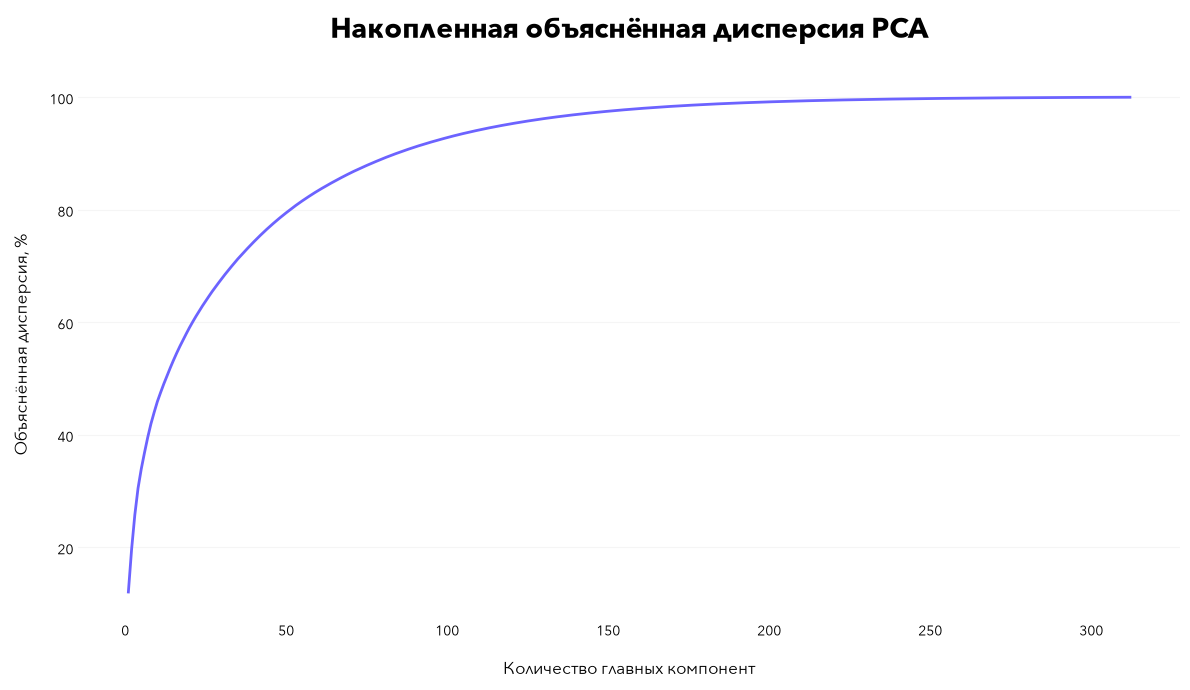

In [16]:
pca_full = PCA()

pca_full.fit(embeddings)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    np.arange(1, len(cumulative_variance) + 1),
    cumulative_variance * 100,
    linewidth=2,
    color="#6C63FF"
)

ax.set_title(
    "Накопленная объяснённая дисперсия PCA",
    fontsize=20,
    fontweight="bold",
    pad=25
)

ax.set_xlabel(
    "Количество главных компонент",
    fontsize=12,
    labelpad=12
)

ax.set_ylabel(
    "Объяснённая дисперсия, %",
    fontsize=12,
    labelpad=12
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.tick_params(axis="both", length=0)

ax.grid(
    True,
    axis="y",
    alpha=0.12
)

plt.tight_layout()
plt.show()

## Трёхмерная визуализация эмбеддингов

Для дополнительного анализа представим эмбеддинги в трёхмерном пространстве.

С помощью PCA исходные 312-мерные векторы преобразуются в три главные компоненты. Полученные координаты позволяют визуально оценить структуру пространства эмбеддингов с учётом третьего направления вариативности.

Данная визуализация используется только для анализа структуры данных. Кластеризация в дальнейшем будет выполняться на исходных 312-мерных эмбеддингах.

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_3d = PCA(n_components=3)
embeddings_3d = pca_3d.fit_transform(embeddings)

print(
    f"Объяснённая дисперсия: "
    f"{pca_3d.explained_variance_ratio_.sum() * 100:.2f}%"
)

Объяснённая дисперсия: 25.75%


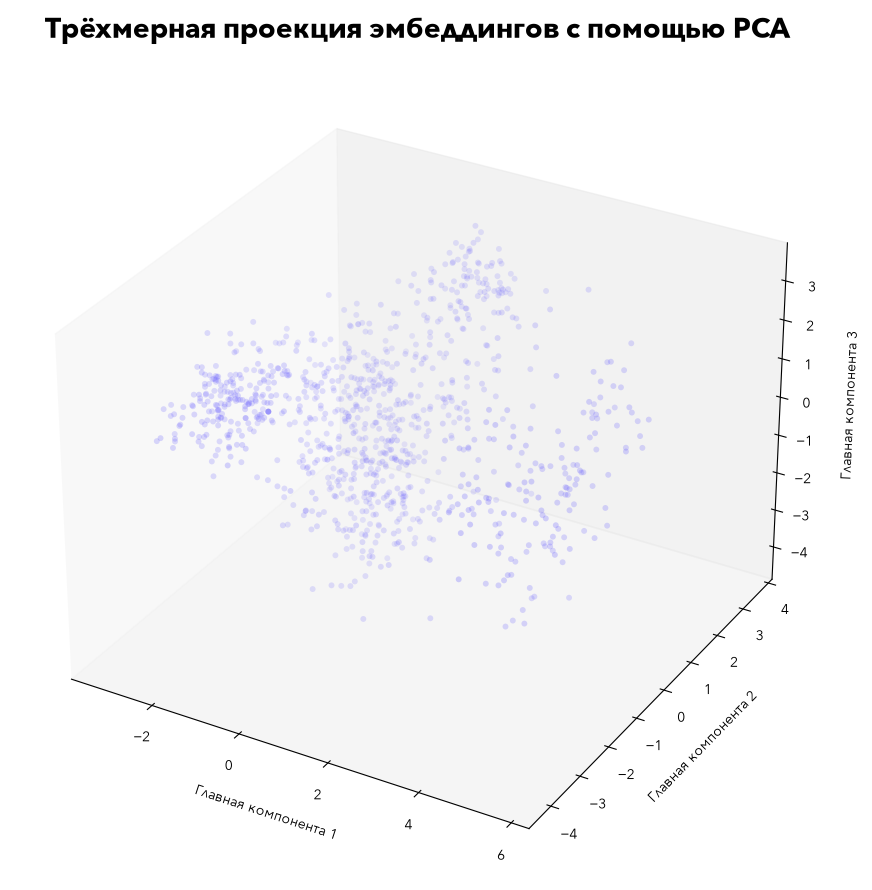

In [19]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    embeddings_3d[:, 0],
    embeddings_3d[:, 1],
    embeddings_3d[:, 2],
    s=18,
    alpha=0.55,
    color="#6C63FF",
    edgecolors="none"
)

ax.set_title(
    "Трёхмерная проекция эмбеддингов с помощью PCA",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Главная компонента 1", labelpad=10)
ax.set_ylabel("Главная компонента 2", labelpad=10)
ax.set_zlabel("Главная компонента 3", labelpad=10)

# Убираем лишний визуальный шум
ax.grid(False)

plt.tight_layout()
plt.show()